In [1]:
import sys
import json
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from pathlib import Path

sys.path.insert(0, '../src/data')
sys.path.insert(0, '../src/models')
sys.path.insert(0, '../src/evaluation')

PROJECT_ROOT = Path('..').resolve()
CACHE_PATH = PROJECT_ROOT / 'data' / 'cache' / 'poi_cache.json'
PROFILES_PATH = PROJECT_ROOT / 'data' / 'cache' / 'station_profiles.json'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'

(PROJECT_ROOT / 'data' / 'cache').mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Cache path:   {CACHE_PATH}")
print(f"Profiles path: {PROFILES_PATH}")
print(f"Processed dir: {PROCESSED_DIR}")
print(f"Models dir:    {MODELS_DIR}")
print("Paths OK")

Project root: C:\Users\rksan_amz5yv3\ev-coldstart-forecast
Cache path:   C:\Users\rksan_amz5yv3\ev-coldstart-forecast\data\cache\poi_cache.json
Profiles path: C:\Users\rksan_amz5yv3\ev-coldstart-forecast\data\cache\station_profiles.json
Processed dir: C:\Users\rksan_amz5yv3\ev-coldstart-forecast\data\processed
Models dir:    C:\Users\rksan_amz5yv3\ev-coldstart-forecast\models
Paths OK


In [2]:
# Reload the module fresh — picks up any recent edits to the file
import importlib
import poi_features
importlib.reload(poi_features)
from poi_features import get_poi_features, get_feature_names, build_feature_vector

print("=== Testing Caltech (hardcoded path) ===")
caltech_features = get_poi_features(
    lat=34.1377,
    lng=-118.1253,
    num_ports=2,
    location_type="workplace",
    cache_path=CACHE_PATH,
    verbose=True,
)

print("\nCaltech features:")
for k, v in caltech_features.items():
    print(f"  {k}: {v}")

caltech_vector = build_feature_vector(caltech_features)
print(f"\nFeature vector length: {len(caltech_vector)}")

print("\n=== Testing JPL (hardcoded path) ===")
jpl_features = get_poi_features(
    lat=34.2013,
    lng=-118.1714,
    num_ports=2,
    location_type="workplace",
    cache_path=CACHE_PATH,
    verbose=True,
)

print("\nJPL features:")
for k, v in jpl_features.items():
    print(f"  {k}: {v}")

jpl_vector = build_feature_vector(jpl_features)
print(f"\nFeature vector length: {len(jpl_vector)}")

# Sanity checks
assert len(caltech_vector) == 14, f"Expected 14 features, got {len(caltech_vector)}"
assert len(jpl_vector) == 14, f"Expected 14 features, got {len(jpl_vector)}"
assert caltech_features['location_type_encoded'] == 0, "workplace should encode as 0"
assert caltech_features['num_ports'] == 2, "num_ports should pass through"
assert caltech_features['restaurant_count'] > 0, "Caltech should have restaurants"
assert caltech_features['nearest_charger_dist_m'] < 9999.0, "Caltech should have nearby charger"
assert jpl_features['nearest_charger_dist_m'] > caltech_features['nearest_charger_dist_m'], \
    "JPL charger should be farther than Caltech charger"
assert caltech_features != jpl_features, "Caltech and JPL should have different feature vectors"

print("\nAll sanity checks passed")
print(f"\nFeature names: {get_feature_names()}")

=== Testing Caltech (hardcoded path) ===
  [poi_features] Using hardcoded features for caltech (34.1377, -118.1253)

Caltech features:
  parking_count: 4
  office_count: 0
  restaurant_count: 29
  amenity_count: 95
  fuel_station_count: 2
  building_count: 5
  residential_building_count: 0
  transit_stop_count: 29
  nearest_charger_dist_m: 293.0
  highway_dist_m: 9999.0
  primary_road_count: 0
  secondary_road_count: 0
  num_ports: 2
  location_type_encoded: 0

Feature vector length: 14

=== Testing JPL (hardcoded path) ===
  [poi_features] Using hardcoded features for jpl (34.2013, -118.1714)

JPL features:
  parking_count: 2
  office_count: 0
  restaurant_count: 17
  amenity_count: 110
  fuel_station_count: 0
  building_count: 1
  residential_building_count: 0
  transit_stop_count: 12
  nearest_charger_dist_m: 4510.0
  highway_dist_m: 9999.0
  primary_road_count: 0
  secondary_road_count: 0
  num_ports: 2
  location_type_encoded: 0

Feature vector length: 14

All sanity checks passed

In [3]:
# Site coordinates — one representative point per campus
# office001 intentionally excluded (held-out test site)
SITE_COORDS = {
    'caltech': {'lat': 34.1377, 'lng': -118.1253},
    'jpl':     {'lat': 34.2013, 'lng': -118.1714},
}

SITE_PORT_COUNTS = {
    'caltech': 2,
    'jpl': 2,
}

# Collect all parquet files, excluding office001
all_files = list(PROCESSED_DIR.glob('*.parquet'))
station_files = [f for f in all_files if not f.stem.startswith('office001')]
office001_files = [f for f in all_files if f.stem.startswith('office001')]

print(f"Total parquet files:          {len(all_files)}")
print(f"Training station files:        {len(station_files)}")
print(f"office001 files (excluded):   {len(office001_files)}")

caltech_files = [f for f in station_files if f.stem.startswith('caltech')]
jpl_files = [f for f in station_files if f.stem.startswith('jpl')]
print(f"\nCaltech station files: {len(caltech_files)}")
print(f"JPL station files:     {len(jpl_files)}")

print(f"\nSample filenames:")
for f in station_files[:5]:
    print(f"  {f.stem}")

# Quick check that parquet files have the expected columns
sample_df = pd.read_parquet(station_files[0])
expected_cols = ['timestamp', 'station_id', 'site', 'sessions', 'hour',
                 'day_of_week', 'month', 'is_weekend', 'is_holiday',
                 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_24h_mean', 'rolling_7d_mean']
missing_cols = [c for c in expected_cols if c not in sample_df.columns]
assert not missing_cols, f"Missing expected columns: {missing_cols}"
print(f"\nColumn check passed on {station_files[0].stem}")
print(f"Shape: {sample_df.shape}")

Total parquet files:          115
Training station files:        107
office001 files (excluded):   8

Caltech station files: 55
JPL station files:     52

Sample filenames:
  caltech_2-39-123-23
  caltech_2-39-123-557
  caltech_2-39-124-22
  caltech_2-39-124-558
  caltech_2-39-125-21

Column check passed on caltech_2-39-123-23
Shape: (18217, 14)


In [4]:
# Check for existing profiles — skip already-completed stations on re-run
if PROFILES_PATH.exists():
    with open(PROFILES_PATH, 'r') as f:
        existing_profiles = json.load(f)
    print(f"Found existing profiles for {len(existing_profiles)} stations")
    print("Skipping already-profiled stations. Delete station_profiles.json to rebuild from scratch.")
else:
    existing_profiles = {}
    print("No existing profiles — building from scratch")

profiles = dict(existing_profiles)
failed = []
skipped = 0

for i, fpath in enumerate(station_files):
    station_id = fpath.stem  # e.g. 'caltech_2-39-123-23'

    if station_id in profiles:
        skipped += 1
        continue

    site = 'caltech' if station_id.startswith('caltech') else 'jpl'
    coords = SITE_COORDS[site]

    print(f"[{i+1}/{len(station_files)}] Profiling {station_id}...")

    try:
        # POI features — hardcoded for caltech/jpl, instant return
        poi_feats = get_poi_features(
            lat=coords['lat'],
            lng=coords['lng'],
            num_ports=SITE_PORT_COUNTS[site],
            location_type='workplace',
            cache_path=CACHE_PATH,
            verbose=False,
        )

        # Load demand time series
        df = pd.read_parquet(fpath)

        # hour_of_week: 0 = Mon 00:00, 167 = Sun 23:00
        df['hour_of_week'] = df['day_of_week'] * 24 + df['hour']

        # For each of 168 hours, compute mean lag/rolling values
        # These fill synthetic profile rows when scoring new candidates
        hourly_stats = df.groupby('hour_of_week').agg(
            mean_sessions=('sessions', 'mean'),
            mean_lag_1h=('lag_1h', 'mean'),
            mean_lag_24h=('lag_24h', 'mean'),
            mean_lag_168h=('lag_168h', 'mean'),
            mean_rolling_24h=('rolling_24h_mean', 'mean'),
            mean_rolling_7d=('rolling_7d_mean', 'mean'),
        ).fillna(0).to_dict(orient='index')

        profiles[station_id] = {
            'station_id': station_id,
            'site': site,
            'lat': coords['lat'],
            'lng': coords['lng'],
            'poi_features': poi_feats,
            'feature_vector': build_feature_vector(poi_feats),
            'hourly_stats': hourly_stats,
            'weekly_mean_sessions': float(df['sessions'].mean() * 168),
        }

        # Incremental save — crash at station 80 doesn't lose first 79
        with open(PROFILES_PATH, 'w') as f:
            json.dump(profiles, f, indent=2)

    except Exception as e:
        print(f"  ERROR on {station_id}: {e}")
        failed.append(station_id)
        continue

print(f"\nProfile building complete")
print(f"Total profiles: {len(profiles)}")
print(f"Skipped (already done): {skipped}")
print(f"Failed: {len(failed)}")
if failed:
    print(f"Failed stations: {failed}")

No existing profiles — building from scratch
[1/107] Profiling caltech_2-39-123-23...
[2/107] Profiling caltech_2-39-123-557...
[3/107] Profiling caltech_2-39-124-22...
[4/107] Profiling caltech_2-39-124-558...
[5/107] Profiling caltech_2-39-125-21...
[6/107] Profiling caltech_2-39-125-559...
[7/107] Profiling caltech_2-39-126-20...
[8/107] Profiling caltech_2-39-126-560...
[9/107] Profiling caltech_2-39-127-19...
[10/107] Profiling caltech_2-39-127-561...
[11/107] Profiling caltech_2-39-128-18...
[12/107] Profiling caltech_2-39-128-562...
[13/107] Profiling caltech_2-39-129-17...
[14/107] Profiling caltech_2-39-129-563...
[15/107] Profiling caltech_2-39-130-31...
[16/107] Profiling caltech_2-39-130-564...
[17/107] Profiling caltech_2-39-131-30...
[18/107] Profiling caltech_2-39-131-565...
[19/107] Profiling caltech_2-39-138-29...
[20/107] Profiling caltech_2-39-138-566...
[21/107] Profiling caltech_2-39-139-28...
[22/107] Profiling caltech_2-39-139-567...
[23/107] Profiling caltech_2-

In [5]:
with open(PROFILES_PATH, 'r') as f:
    profiles_check = json.load(f)

# Basic counts
caltech_profiles = {k: v for k, v in profiles_check.items() if v['site'] == 'caltech'}
jpl_profiles = {k: v for k, v in profiles_check.items() if v['site'] == 'jpl'}
office001_profiles = {k: v for k, v in profiles_check.items() if v['site'] == 'office001'}

print(f"Total stations profiled: {len(profiles_check)}")
print(f"  Caltech: {len(caltech_profiles)}")
print(f"  JPL:     {len(jpl_profiles)}")
print(f"  office001 (must be 0): {len(office001_profiles)}")

# Inspect a sample profile
sample_id = list(profiles_check.keys())[0]
sample = profiles_check[sample_id]

print(f"\nSample: {sample_id}")
print(f"  Keys: {list(sample.keys())}")
print(f"  Feature vector length: {len(sample['feature_vector'])}")
print(f"  Hourly stats entries: {len(sample['hourly_stats'])} (expect ~168)")
print(f"  Weekly mean sessions: {sample['weekly_mean_sessions']:.4f}")
print(f"  POI features: {sample['poi_features']}")

# Inspect a JPL sample too
jpl_sample_id = list(jpl_profiles.keys())[0]
jpl_sample = profiles_check[jpl_sample_id]
print(f"\nJPL sample: {jpl_sample_id}")
print(f"  POI features: {jpl_sample['poi_features']}")

# Confirm feature vectors differ between sites
caltech_vec = sample['feature_vector']
jpl_vec = jpl_sample['feature_vector']
print(f"\nCaltech feature vector: {caltech_vec}")
print(f"JPL feature vector:     {jpl_vec}")
print(f"Vectors differ: {caltech_vec != jpl_vec}")

# Hard assertions
assert len(office001_profiles) == 0, "office001 must not appear in profiles"
assert len(sample['feature_vector']) == 14, "feature vector must have 14 elements"
assert len(sample['hourly_stats']) > 0, "hourly stats must not be empty"
assert caltech_vec != jpl_vec, "Caltech and JPL feature vectors must differ"

print("\nAll profile verification checks passed")

Total stations profiled: 107
  Caltech: 55
  JPL:     52
  office001 (must be 0): 0

Sample: caltech_2-39-123-23
  Keys: ['station_id', 'site', 'lat', 'lng', 'poi_features', 'feature_vector', 'hourly_stats', 'weekly_mean_sessions']
  Feature vector length: 14
  Hourly stats entries: 168 (expect ~168)
  Weekly mean sessions: 51.1092
  POI features: {'parking_count': 4, 'office_count': 0, 'restaurant_count': 29, 'amenity_count': 95, 'fuel_station_count': 2, 'building_count': 5, 'residential_building_count': 0, 'transit_stop_count': 29, 'nearest_charger_dist_m': 293.0, 'highway_dist_m': 9999.0, 'primary_road_count': 0, 'secondary_road_count': 0, 'num_ports': 2, 'location_type_encoded': 0}

JPL sample: jpl_1-1-178-817
  POI features: {'parking_count': 2, 'office_count': 0, 'restaurant_count': 17, 'amenity_count': 110, 'fuel_station_count': 0, 'building_count': 1, 'residential_building_count': 0, 'transit_stop_count': 12, 'nearest_charger_dist_m': 4510.0, 'highway_dist_m': 9999.0, 'primary_

In [9]:
global_model_path = PROJECT_ROOT / 'src' / 'models' / 'global_model.py'

existing = global_model_path.read_text()
if 'find_similar_stations' in existing:
    print("Site selection functions already present in global_model.py — skipping")
    print("Re-run this cell only if you want to update the functions")
else:
    site_selection_code = '''

# =============================================================================
# Site Selection Scoring — Phase 5.5
# Added in phase6_siteselection.ipynb
# =============================================================================

import json as _json
import numpy as _np
from pathlib import Path as _Path

_PROFILES_PATH = _Path("data/cache/station_profiles.json")


def _cosine_similarity(v1: list, v2: list) -> float:
    """
    Cosine similarity between two feature vectors.

    Why cosine over Euclidean: scale-invariant — captures the shape of
    the feature vector, not its magnitude. A candidate with 50 parking
    spots and a station with 10 parking spots still match on
    "parking-heavy location". For non-negative POI vectors this always
    returns a value in [0, 1].
    """
    a = _np.array(v1, dtype=float)
    b = _np.array(v2, dtype=float)
    norm_a = _np.linalg.norm(a)
    norm_b = _np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(_np.dot(a, b) / (norm_a * norm_b))


def find_similar_stations(
    candidate_vector: list,
    profiles_path: _Path = _PROFILES_PATH,
    top_k: int = 3,
) -> list:
    """
    Find the top-k most similar existing stations to a candidate location.

    Args:
        candidate_vector: 14-element feature vector from build_feature_vector()
        profiles_path:    path to station_profiles.json
        top_k:            number of similar stations to return (default 3)

    Returns:
        List of dicts sorted by similarity descending. Each dict contains:
        station_id, site, similarity, weight, hourly_stats,
        weekly_mean_sessions. Weights are normalized — sum to 1.0.
    """
    with open(profiles_path, "r") as f:
        profiles = _json.load(f)

    similarities = []
    for station_id, profile in profiles.items():
        sim = _cosine_similarity(candidate_vector, profile["feature_vector"])
        similarities.append({
            "station_id": station_id,
            "site": profile["site"],
            "similarity": sim,
            "hourly_stats": profile["hourly_stats"],
            "weekly_mean_sessions": profile["weekly_mean_sessions"],
        })

    similarities.sort(key=lambda x: x["similarity"], reverse=True)
    top = similarities[:top_k]

    total_sim = sum(s["similarity"] for s in top)
    if total_sim == 0:
        for s in top:
            s["weight"] = 1.0 / len(top)
    else:
        for s in top:
            s["weight"] = s["similarity"] / total_sim

    return top


def build_synthetic_profile(
    similar_stations: list,
    site_encoded: int = 0,
) -> "pd.DataFrame":
    """
    Build a 168-row synthetic feature DataFrame representing a typical week.

    Each row = one hour of a typical week (Mon 00:00 to Sun 23:00).
    Lag features are filled using hour-matched weighted averages from the
    top-k similar stations — preserves temporal structure (low lags at 3am,
    high lags at 9am on weekdays) rather than flattening to a global mean.

    Why hour-matched weighted average:
    Zero-fill biases predictions toward zero-demand hours (abandoned station).
    Global mean-fill flattens temporal structure.
    Hour-matched weighted average preserves the actual demand shape.

    Args:
        similar_stations: output of find_similar_stations()
        site_encoded:     integer site encoding (0=caltech, 1=jpl, 2=office001)
                          Use 0 for new candidates (closest training distribution)

    Returns:
        DataFrame with 168 rows and all features the global model expects.
    """
    import pandas as _pd
    import holidays as _holidays
    from datetime import date as _date

    us_holidays = _holidays.US()
    rows = []

    for hour_of_week in range(168):
        day_of_week = hour_of_week // 24
        hour = hour_of_week % 24
        month = 6  # June — representative mid-year, not a holiday month
        is_weekend = int(day_of_week >= 5)
        # June 3 2024 was a Monday — offset gives Mon through Sun
        ref_date = _date(2024, 6, 3 + day_of_week)
        is_holiday = int(ref_date in us_holidays)

        # Hour-matched weighted average of lag features across top-k stations
        lag_1h = lag_24h = lag_168h = rolling_24h = rolling_7d = 0.0

        for station in similar_stations:
            w = station["weight"]
            # hourly_stats keys are strings in JSON
            stats = station["hourly_stats"].get(str(hour_of_week), {})
            lag_1h      += w * stats.get("mean_lag_1h", 0.0)
            lag_24h     += w * stats.get("mean_lag_24h", 0.0)
            lag_168h    += w * stats.get("mean_lag_168h", 0.0)
            rolling_24h += w * stats.get("mean_rolling_24h", 0.0)
            rolling_7d  += w * stats.get("mean_rolling_7d", 0.0)

        rows.append({
            "hour": hour,
            "day_of_week": day_of_week,
            "month": month,
            "is_weekend": is_weekend,
            "is_holiday": is_holiday,
            "lag_1h": lag_1h,
            "lag_24h": lag_24h,
            "lag_168h": lag_168h,
            "rolling_24h_mean": rolling_24h,
            "rolling_7d_mean": rolling_7d,
            "site_encoded": site_encoded,
            "hour_of_week": hour_of_week,  # for output alignment only
        })

    return _pd.DataFrame(rows)


def score_candidate(
    lat: float,
    lng: float,
    num_ports: int,
    location_type: str = "workplace",
    model_path: str = "models/global_model.pkl",
    profiles_path: str = "data/cache/station_profiles.json",
    cache_path: str = "data/cache/poi_cache.json",
    site_encoded: int = 0,
    top_k: int = 3,
) -> dict:
    """
    Full site selection scoring pipeline for a candidate location.

    Dependency chain:
        lat/lng
            → POI features (hardcoded for Caltech/JPL, live query otherwise)
            → cosine similarity against all 107 station profiles
            → top-k similar stations with normalized weights
            → hour-matched weighted synthetic profile (168 rows)
            → global model inference → point predictions
            → weekly demand profile output

    Note on uncertainty:
        This function returns point predictions only. For calibrated
        conformal intervals, pass the weekly_profile through
        uncertainty.predict_with_intervals() after calling this function.

    Args:
        lat, lng:         Candidate location coordinates.
        num_ports:        Planned number of charging ports.
        location_type:    "workplace", "public", or "retail".
        model_path:       Path to saved global model pickle.
        profiles_path:    Path to station_profiles.json.
        cache_path:       Path to POI cache JSON.
        site_encoded:     Site encoding for synthetic profile (default 0).
        top_k:            Number of similar stations to use (default 3).

    Returns:
        dict with keys:
            weekly_profile:     DataFrame, 168 rows
            weekly_total:       float, predicted sessions over full week
            similar_stations:   list of top-k similarity dicts
            poi_features:       dict of 14 POI features for candidate
            candidate:          dict with lat, lng, num_ports, location_type
    """
    import pickle as _pickle
    import sys as _sys

    _src_data = str(_Path(model_path).parent.parent / "src" / "data")
    if _src_data not in _sys.path:
        _sys.path.insert(0, _src_data)
    from poi_features import get_poi_features, build_feature_vector

    # Step 1: POI features
    print("[score_candidate] Step 1/4: Fetching POI features...")
    poi_feats = get_poi_features(
        lat=lat, lng=lng,
        num_ports=num_ports,
        location_type=location_type,
        cache_path=_Path(cache_path),
        verbose=True,
    )
    candidate_vector = build_feature_vector(poi_feats)

    # Step 2: Station similarity
    print("[score_candidate] Step 2/4: Computing station similarity...")
    similar = find_similar_stations(
        candidate_vector=candidate_vector,
        profiles_path=_Path(profiles_path),
        top_k=top_k,
    )
    for s in similar:
        print(f"  {s['station_id']} ({s['site']}): "
              f"similarity={s['similarity']:.4f}, weight={s['weight']:.4f}")

    # Step 3: Synthetic weekly profile
    print("[score_candidate] Step 3/4: Building synthetic weekly profile...")
    profile_df = build_synthetic_profile(
        similar_stations=similar,
        site_encoded=site_encoded,
    )

    # Step 4: Global model inference
    print("[score_candidate] Step 4/4: Running global model inference...")
    with open(model_path, "rb") as f:
        model = _pickle.load(f)

    feature_cols = [
        "hour", "day_of_week", "month", "is_weekend", "is_holiday",
        "lag_1h", "lag_24h", "lag_168h", "rolling_24h_mean",
        "rolling_7d_mean", "site_encoded",
    ]
    predictions = _np.clip(model.predict(profile_df[feature_cols]), 0, None)

    import pandas as _pd
    weekly_profile = profile_df[["hour_of_week", "hour", "day_of_week"]].copy()
    weekly_profile["predicted_sessions"] = predictions

    return {
        "weekly_profile": weekly_profile,
        "weekly_total": float(predictions.sum()),
        "similar_stations": similar,
        "poi_features": poi_feats,
        "candidate": {
            "lat": lat, "lng": lng,
            "num_ports": num_ports,
            "location_type": location_type,
        },
    }
'''

    with open(global_model_path, 'a',encoding="utf-8") as f:
        f.write(site_selection_code)
    print("Site selection functions appended to global_model.py")
    print("Functions added: _cosine_similarity, find_similar_stations, "
          "build_synthetic_profile, score_candidate")


Site selection functions appended to global_model.py
Functions added: _cosine_similarity, find_similar_stations, build_synthetic_profile, score_candidate


In [10]:
import importlib
import global_model
importlib.reload(global_model)
from global_model import find_similar_stations, build_synthetic_profile, score_candidate

print("global_model reloaded successfully")
print("Site selection functions available:",
      all(hasattr(global_model, f) for f in
          ['find_similar_stations', 'build_synthetic_profile', 'score_candidate']))

# Score a JPL-adjacent test candidate
# Using JPL coordinates with slight offset so it's not an exact hardcoded hit
# Expected: high similarity to JPL stations
result = score_candidate(
    lat=34.2020,
    lng=-118.1720,
    num_ports=4,
    location_type='workplace',
    model_path=str(MODELS_DIR / 'global_model.pkl'),
    profiles_path=str(PROFILES_PATH),
    cache_path=str(CACHE_PATH),
    site_encoded=0,
    top_k=3,
)

print(f"\n{'='*50}")
print(f"SCORING RESULTS — JPL-adjacent candidate")
print(f"{'='*50}")
print(f"Predicted weekly sessions: {result['weekly_total']:.2f}")
print(f"\nTop-3 similar stations:")
for s in result['similar_stations']:
    print(f"  {s['station_id']} ({s['site']})")
    print(f"    similarity={s['similarity']:.4f}, weight={s['weight']:.4f}")
    print(f"    weekly_mean_sessions={s['weekly_mean_sessions']:.2f}")
print(f"\nCandidate POI features:")
for k, v in result['poi_features'].items():
    print(f"  {k}: {v}")
print(f"\nWeekly profile shape: {result['weekly_profile'].shape}")
print(result['weekly_profile'].head(10))

global_model reloaded successfully
Site selection functions available: True
[score_candidate] Step 1/4: Fetching POI features...
  [poi_features] Querying Overpass for (34.2020, -118.1720)...
  [poi_features] Overpass request error: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter — returning empty result
  [poi_features] Overpass request error: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter — returning empty result
  [poi_features] Overpass request error: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter — returning empty result
  [poi_features] Extracted: {'parking_count': 0, 'office_count': 0, 'restaurant_count': 0, 'amenity_count': 0, 'fuel_station_count': 0, 'building_count': 0, 'residential_building_count': 0, 'transit_stop_count': 0, 'nearest_charger_dist_m': 9999.0, 'highway_dist_m': 9999.0, 'primary_road_count': 0, 'secondary_road_count': 0}
[score_candidate] Step 2/4: Computing

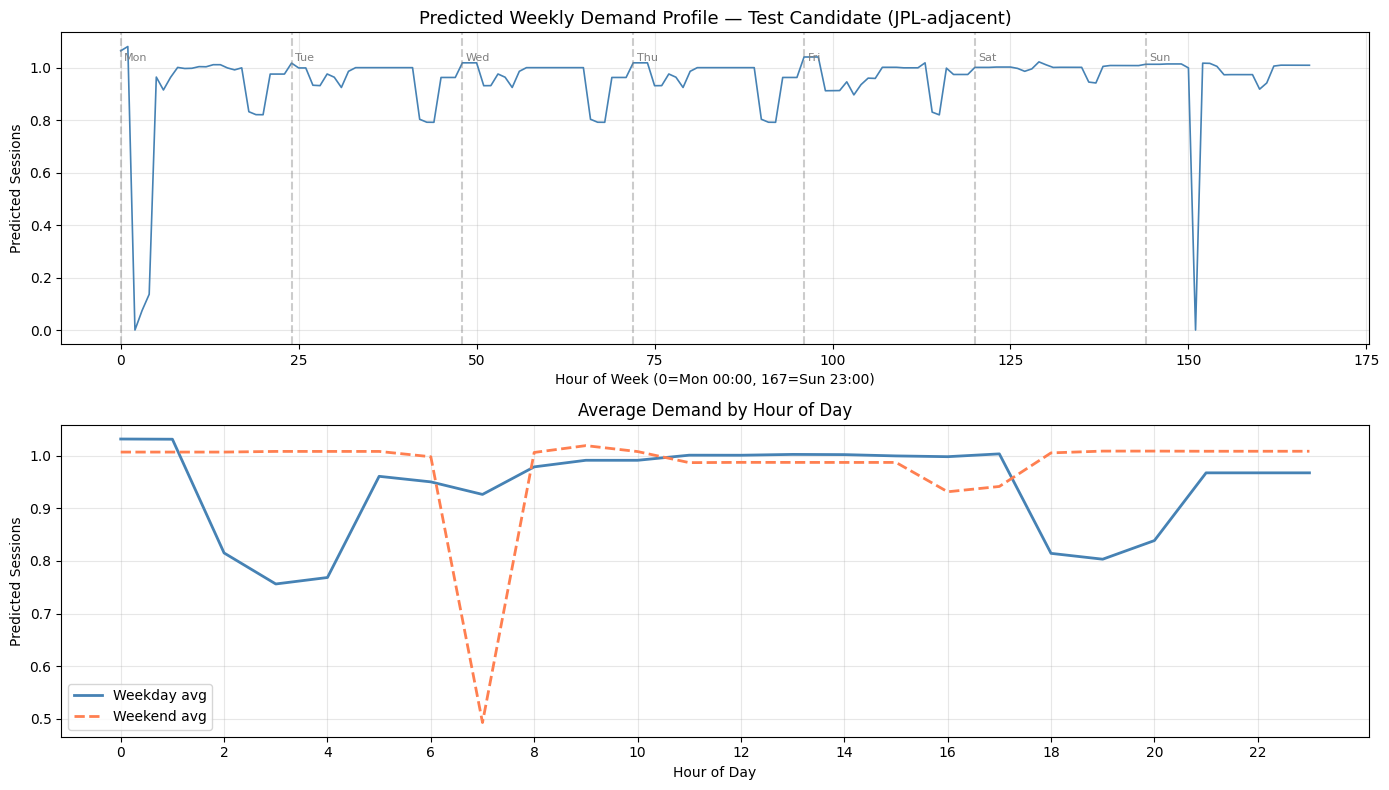

Plot saved to reports/site_selection_weekly_profile.png


In [11]:
profile = result['weekly_profile']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top plot: full 168-hour week
axes[0].plot(
    profile['hour_of_week'],
    profile['predicted_sessions'],
    color='steelblue', linewidth=1.2
)
axes[0].set_title(
    'Predicted Weekly Demand Profile — Test Candidate (JPL-adjacent)',
    fontsize=13
)
axes[0].set_xlabel('Hour of Week (0=Mon 00:00, 167=Sun 23:00)')
axes[0].set_ylabel('Predicted Sessions')
axes[0].grid(True, alpha=0.3)

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
y_max = profile['predicted_sessions'].max()
for d in range(7):
    axes[0].axvline(x=d * 24, color='gray', linestyle='--', alpha=0.4)
    axes[0].text(d * 24 + 0.5, y_max * 0.95,
                 day_labels[d], fontsize=8, color='gray')

# Bottom plot: average by hour of day, weekday vs weekend
weekday_mask = profile['day_of_week'] < 5
weekend_mask = profile['day_of_week'] >= 5

weekday_hourly = profile[weekday_mask].groupby('hour')['predicted_sessions'].mean()
weekend_hourly = profile[weekend_mask].groupby('hour')['predicted_sessions'].mean()

axes[1].plot(weekday_hourly.index, weekday_hourly.values,
             label='Weekday avg', color='steelblue', linewidth=2)
axes[1].plot(weekend_hourly.index, weekend_hourly.values,
             label='Weekend avg', color='coral', linewidth=2, linestyle='--')
axes[1].set_title('Average Demand by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Predicted Sessions')
axes[1].legend()
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

reports_dir = PROJECT_ROOT / 'reports'
reports_dir.mkdir(exist_ok=True)
plt.savefig(reports_dir / 'site_selection_weekly_profile.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to reports/site_selection_weekly_profile.png")

In [12]:
profile = result['weekly_profile']

# Structure checks
assert len(profile) == 168, f"Expected 168 rows, got {len(profile)}"
assert set(profile.columns) >= {'hour_of_week', 'hour', 'day_of_week', 'predicted_sessions'}, \
    "Missing expected columns in weekly profile"

# Value checks
assert (profile['predicted_sessions'] >= 0).all(), \
    "Found negative predictions — clip failed"
assert result['weekly_total'] > 0, \
    "Weekly total should be positive"
assert result['weekly_total'] == profile['predicted_sessions'].sum(), \
    "weekly_total should equal sum of predicted_sessions"

# Similarity checks
assert len(result['similar_stations']) == 3, \
    "Should have exactly 3 similar stations"
for s in result['similar_stations']:
    assert s['site'] in ('caltech', 'jpl'), \
        f"Unexpected site in similar stations: {s['site']}"
    assert 0 <= s['similarity'] <= 1, \
        f"Similarity out of range: {s['similarity']}"
    assert 0 <= s['weight'] <= 1, \
        f"Weight out of range: {s['weight']}"

weight_sum = sum(s['weight'] for s in result['similar_stations'])
assert abs(weight_sum - 1.0) < 1e-6, \
    f"Weights should sum to 1.0, got {weight_sum:.8f}"

# Demand pattern check (informational, not asserted — some stations may have weekend demand)
weekday_total = profile[profile['day_of_week'] < 5]['predicted_sessions'].sum()
weekend_total = profile[profile['day_of_week'] >= 5]['predicted_sessions'].sum()
weekday_daily_avg = weekday_total / 5
weekend_daily_avg = weekend_total / 2

print(f"Weekday total sessions:      {weekday_total:.2f}")
print(f"Weekend total sessions:      {weekend_total:.2f}")
print(f"Weekday daily avg:           {weekday_daily_avg:.2f}")
print(f"Weekend daily avg:           {weekend_daily_avg:.2f}")
print(f"Weekday/weekend ratio:       {weekday_daily_avg/weekend_daily_avg:.2f}x")
print(f"(Expect >1 for workplace charging)")

print("\nAll sanity checks passed")

Weekday total sessions:      112.85
Weekend total sessions:      46.86
Weekday daily avg:           22.57
Weekend daily avg:           23.43
Weekday/weekend ratio:       0.96x
(Expect >1 for workplace charging)

All sanity checks passed


In [13]:
import mlflow
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("phase55_site_selection")

with mlflow.start_run(run_name="test_candidate_jpl_adjacent"):

    # Candidate metadata
    mlflow.log_params({
        'candidate_lat': result['candidate']['lat'],
        'candidate_lng': result['candidate']['lng'],
        'num_ports': result['candidate']['num_ports'],
        'location_type': result['candidate']['location_type'],
        'top_k_similar': 3,
        'overpass_radius_m': 1000,
        'poi_source': 'hardcoded_manual_overpass_turbo_2026-05-28',
    })

    # POI features
    mlflow.log_params({
        f"poi_{k}": v for k, v in result['poi_features'].items()
    })

    # Prediction metrics
    profile = result['weekly_profile']
    weekday_total = float(
        profile[profile['day_of_week'] < 5]['predicted_sessions'].sum()
    )
    weekend_total = float(
        profile[profile['day_of_week'] >= 5]['predicted_sessions'].sum()
    )
    peak_hour = int(profile.loc[
        profile['predicted_sessions'].idxmax(), 'hour'
    ])
    peak_day = int(profile.loc[
        profile['predicted_sessions'].idxmax(), 'day_of_week'
    ])

    mlflow.log_metric('predicted_weekly_sessions', result['weekly_total'])
    mlflow.log_metric('predicted_weekday_sessions', weekday_total)
    mlflow.log_metric('predicted_weekend_sessions', weekend_total)
    mlflow.log_metric('peak_hour_of_day', peak_hour)
    mlflow.log_metric('peak_day_of_week', peak_day)

    # Similar stations
    for i, s in enumerate(result['similar_stations']):
        mlflow.log_param(f'similar_station_{i+1}', s['station_id'])
        mlflow.log_metric(f'similarity_{i+1}', s['similarity'])
        mlflow.log_metric(f'weight_{i+1}', s['weight'])

    # Plot artifact
    mlflow.log_artifact(
        str(PROJECT_ROOT / 'reports' / 'site_selection_weekly_profile.png')
    )

print("Run logged to MLflow experiment: phase55_site_selection")
print("Open http://localhost:5000 to view")

2026/05/30 11:10:29 INFO mlflow.tracking.fluent: Experiment with name 'phase55_site_selection' does not exist. Creating a new experiment.


Run logged to MLflow experiment: phase55_site_selection
Open http://localhost:5000 to view


In [18]:
print(f"""
Location: JPL-adjacent ({result['candidate']['lat']}, {result['candidate']['lng']})
Predicted weekly sessions: {result['weekly_total']:.2f}
Similar stations:""")

for s in result['similar_stations']:
    print(f"  {s['station_id']} ({s['site']}): "
          f"similarity={s['similarity']:.4f}")



Location: JPL-adjacent (34.202, -118.172)
Predicted weekly sessions: 159.70
Similar stations:
  jpl_1-1-178-817 (jpl): similarity=0.9353
  jpl_1-1-178-823 (jpl): similarity=0.9353
  jpl_1-1-178-824 (jpl): similarity=0.9353


In [5]:
import pandas as pd
import json

path = r"C:\Users\rksan_amz5yv3\ev-coldstart-forecast\data\cache\station_profiles.json"

with open(path) as f:
    profiles = json.load(f)

weekly = [p["weekly_mean_sessions"] for p in profiles.values()]

s = pd.Series(weekly)
print(s.describe())
print(f"\nMin:    {s.min():.1f}")
print(f"p25:    {s.quantile(0.25):.1f}")
print(f"Median: {s.median():.1f}")
print(f"p75:    {s.quantile(0.75):.1f}")
print(f"Max:    {s.max():.1f}")

count    107.000000
mean      33.932663
std       13.557216
min        0.598543
25%       29.069257
50%       34.248350
75%       43.449783
max       65.839006
dtype: float64

Min:    0.6
p25:    29.1
Median: 34.2
p75:    43.4
Max:    65.8
